Inputs:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

In [2]:
#setting path to file as it s in a different folder
file_path = "MachineLearningCVE/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv"

#we load one csv for now, mentioning that the memory is not low to prevent warnings about the file being too big
df = pd.read_csv(file_path, low_memory=False)

#cleaning up the columns names because there are spaced in the dataset 
df.columns = df.columns.str.strip()

#checking size for now
print(f"Dataset shape: {df.shape[0]} rows and {df.shape[1]} columns")

#and then checking first 5 rows too
display(df.head())

Dataset shape: 286467 rows and 79 columns


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,22,1266342,41,44,2664,6954,456,0,64.975610,109.864573,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,22,1319353,41,44,2664,6954,456,0,64.975610,109.864573,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,22,160,1,1,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,22,1303488,41,42,2728,6634,456,0,66.536585,110.129945,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,35396,77,1,2,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [3]:
#checking the imbalance
print("Traffic Distribution:")
print(df['Label'].value_counts())

#for this specific csv, what is interesting to notice is th fact that the number of attacks is overwhelming the normal traffic
#this doesn't happen often, and it wont remain like this after we actually combine all the csvs

Traffic Distribution:
Label
PortScan    158930
BENIGN      127537
Name: count, dtype: int64


In [4]:
#now for the cleaning, we need to get rid of useless things like the rows with missing values
#made df_clean because it it's good practice to work directly on our original 
df_clean = df.dropna()

#we then replace the infinity values (fun fact: they are usually caused by division by 0 in network flows)
df_clean = df_clean.replace([np.inf, -np.inf], np.nan).dropna()

#for cleaner labels for out ml, we convert benign to 0 and port scan to 1
df_clean['Label'] = df_clean['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

#printing to check 
print(f"Original Shape: {df.shape}" )
print(f"Cleaned Shape: {df_clean.shape}")

print("\n New Label distribution (0 = Benign, 1 = Port Scan Attack): ")
print(df_clean['Label'].value_counts())

Original Shape: (286467, 79)
Cleaned Shape: (286096, 79)

 New Label distribution (0 = Benign, 1 = Port Scan Attack): 
Label
1    158804
0    127292
Name: count, dtype: int64


In [5]:
#we get into the separating of data, needing to have Features (X) and Target (y)
#Features will be made of all the columns without the Labels
#and Target will only be the Label

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

X = df_clean.drop('Label', axis=1)
y = df_clean['Label']

#splitting the data for training and testing, usually taken as 80% - 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#checking shape
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")



Training data shape: (228876, 78)
Testing data shape: (57220, 78)


In [6]:
#initializing and training the random forest 
rf_model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=1)
rf_model.fit(X_train, y_train)

#le prediction
y_pred = rf_model.predict(X_test)

#evaluating model
print("\n--- Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Benign (0)', 'PortScan (1)']))

#beautiful 100, look at that 


--- Model Evaluation ---
Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

  Benign (0)       1.00      1.00      1.00     25459
PortScan (1)       1.00      1.00      1.00     31761

    accuracy                           1.00     57220
   macro avg       1.00      1.00      1.00     57220
weighted avg       1.00      1.00      1.00     57220



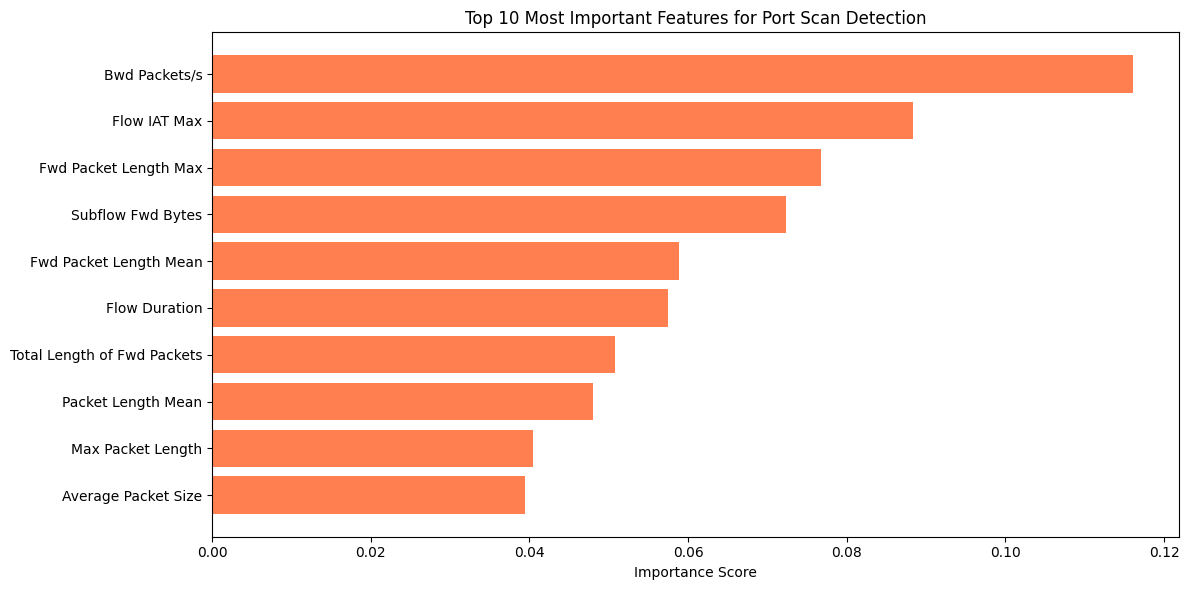

Top 5 Features driving the accuracy %:


,Feature,Importance
37,Bwd Packets/s,0.116131
18,Flow IAT Max,0.088380
6,Fwd Packet Length Max,0.076814
63,Subflow Fwd Bytes,0.072344
8,Fwd Packet Length Mean,0.058875


In [7]:
#let's do a bit of visualization!
#we will be using Feature Importance, so we can ask our rain forest what it cared about when it looked at those 78 columns

importances = rf_model.feature_importances_
feature_names = X.columns

#i will put what i extracted in a data frame so i can sort them easily
features_df = pd.DataFrame({'Feature':feature_names, 'Importance':importances})
features_df = features_df.sort_values(by='Importance', ascending=False)

top_10_features = features_df.head(10)

#plotting ;(
plt.figure(figsize=(12, 6))
plt.barh(top_10_features['Feature'], top_10_features['Importance'], color='coral')
plt.gca().invert_yaxis() #puts the highest importance at the top
plt.title('Top 10 Most Important Features for Port Scan Detection')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("Top 5 Features driving the accuracy %:")
display(top_10_features.head(5))

so first i decided to train that random forest and see how it works and perform, to understand the data and successfully identify the top ten features important for a port scan.
next, i decided to scale the data and benchmark 6 different industry-standard models against each other so i can find an optimal balance between accuracy and the training time used.

In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, recall_score
import time

#print("Scaling data for Neural Networks and Logistic Regression.")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
#defining the models as a dictionary of them 
#for mlp i will keep the iterations a bit lower so it doesn't take too much time

models = {
    "Decision Tree" : DecisionTreeClassifier(random_state=42),
    "Random Forest" : RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1),
    "XGBoost" : XGBClassifier(eval_metric='logloss',random_state=42),
    "LightBDM" : LGBMClassifier(random_state=42, verbose=-1),

    "Logistic Regression" : LogisticRegression(max_iter=1000, random_state=42),
    "MLP (Neural Net)" : MLPClassifier(hidden_layer_sizes=(50,), max_iter=100, random_state=42)
}

results = [] #to store what we find

In [10]:
for name, model in models.items():
    print(f"Training {name}: ")
    start_time = time.time()

    #i will train the model using the scaled data i got earlier so i can keep things fair 
    model.fit(X_train_scaled, y_train)

    #predicting
    y_pred_all = model.predict(X_test_scaled)
    train_time = time.time() - start_time

    #calculating the end score
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)

    #saving them in results
    results.append({
        "Model" : name,
        "Accuracy (%)" : round(acc*100, 4),
        "Recall (Attack Catch Rate)": round(recall * 100, 4),
        "F1-Score": round(f1, 4),
        "Training Time (s)": round(train_time, 2)
    })

Training Decision Tree: 
Training Random Forest: 
Training XGBoost: 
Training LightBDM: 


c:\Users\Magda\Desktop\AnomalyDetection\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Training Logistic Regression: 
Training MLP (Neural Net): 


In [11]:
#showing the results
results_df = pd.DataFrame(results).sort_values(by="Accuracy (%)", ascending=False)
print("\nFinal Model Leaderboard:")
display(results_df)


Final Model Leaderboard:


,Model,Accuracy (%),Recall (Attack Catch Rate),F1-Score,Training Time (s)
0,Decision Tree,99.9965,99.9969,1.0,6.77
1,Random Forest,99.9965,99.9969,1.0,6.68
2,XGBoost,99.9965,99.9969,1.0,4.36
3,LightBDM,99.9965,99.9969,1.0,12.72
4,Logistic Regression,99.9965,99.9969,1.0,5.59
5,MLP (Neural Net),99.9965,99.9969,1.0,80.29


A small thing we can notice is the fact that compared to earlier our random forest has dropped a bit in accuracy and that is because we have scaled our data. Tree based models don t need scaled data. In fact scaling the data will result in exactly what happened earlier. Because i got the data from an integer into a floating-point decimal, when random forest tried to calculate the exact math boundaries to split the tree , those small decimal differences made it misclassify 2(?) packets 

Scaling is mandatory for neural networks to function, not for tree based things.

Now if i am to look over the leaderboard and actually analyze it a bit more, i can notice the fact that XGBoost has performed best for the data it has received. Comparing to MLP, which is the longest, we can see it took 15 times more for this neural network

This is a beautiful example for a concept from cybersecurity in showing how deep learning is not always the answer. For the structured, tabular network data, advanced tree models like xgboost, decision tree and random forest are more efficient than neural networks. This saves crucial time and server costs if we are to apply it in a real scenario